In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [26]:
gold_ticker = 'GC=F'   # Gold Futures
dxy_ticker = 'DX-Y.NYB' # US Dollar Index
start_date = '2014-01-01'
end_date = '2024-12-31' 

# Fetch data
gold_data = yf.download(gold_ticker, start=start_date, end=end_date)
dxy_data = yf.download(dxy_ticker, start=start_date, end=end_date)

/var/folders/7r/lgn82cw53yj2xmlwrdbj46n40000gn/T/ipykernel_35507/2792047084.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download(gold_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/7r/lgn82cw53yj2xmlwrdbj46n40000gn/T/ipykernel_35507/2792047084.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dxy_data = yf.download(dxy_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [27]:
df = pd.DataFrame()
df['Gold'] = gold_data['Close']
df['DXY'] = dxy_data['Close']

# Drop rows with missing values (NaN)
df.dropna(inplace=True)

print(f"Data from {df.index.min()} to {df.index.max()}")
print(df.head())

Data from 2014-01-02 00:00:00 to 2024-12-30 00:00:00
                   Gold        DXY
Date                              
2014-01-02  1225.000000  80.629997
2014-01-03  1238.400024  80.790001
2014-01-06  1237.800049  80.650002
2014-01-07  1229.400024  80.830002
2014-01-08  1225.300049  81.040001


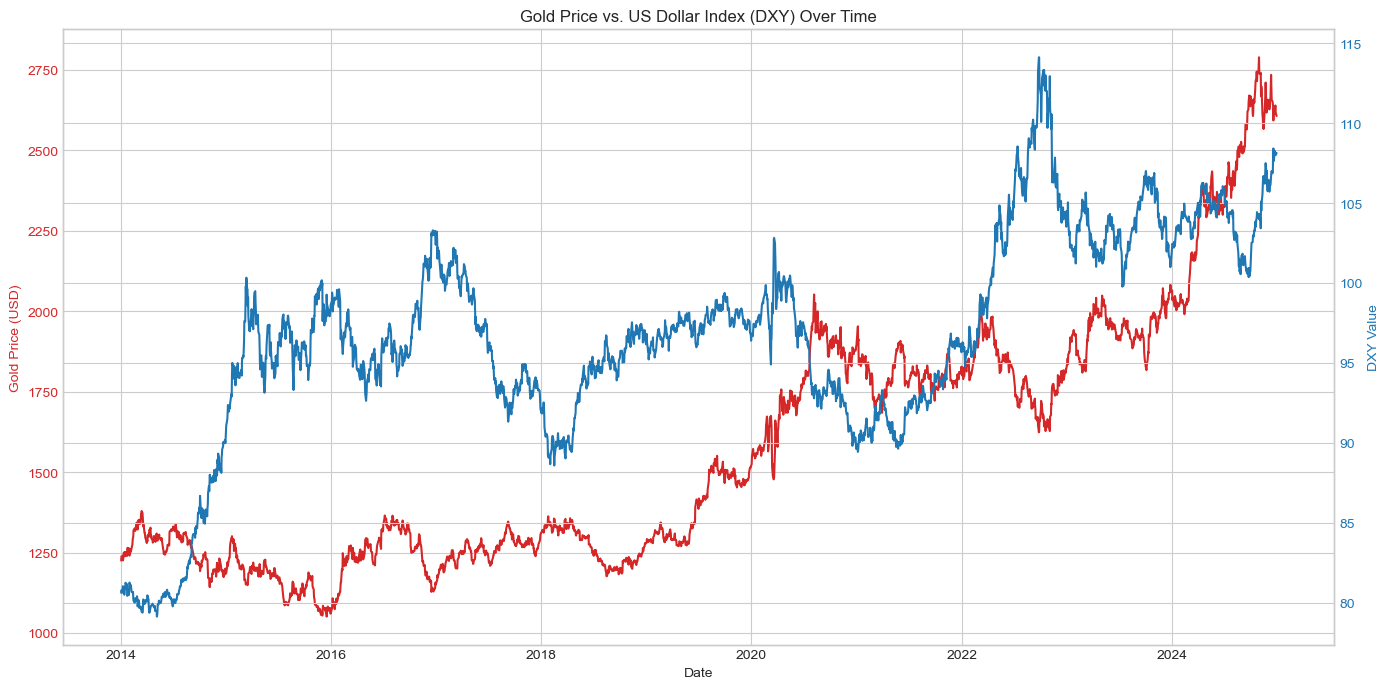

In [28]:
fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Gold Price (USD)', color=color)
ax1.plot(df.index, df['Gold'], color=color, label='Gold Price')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('DXY Value', color=color)
ax2.plot(df.index, df['DXY'], color=color, label='DXY')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Gold Price vs. US Dollar Index (DXY) Over Time')
fig.tight_layout()
plt.show()

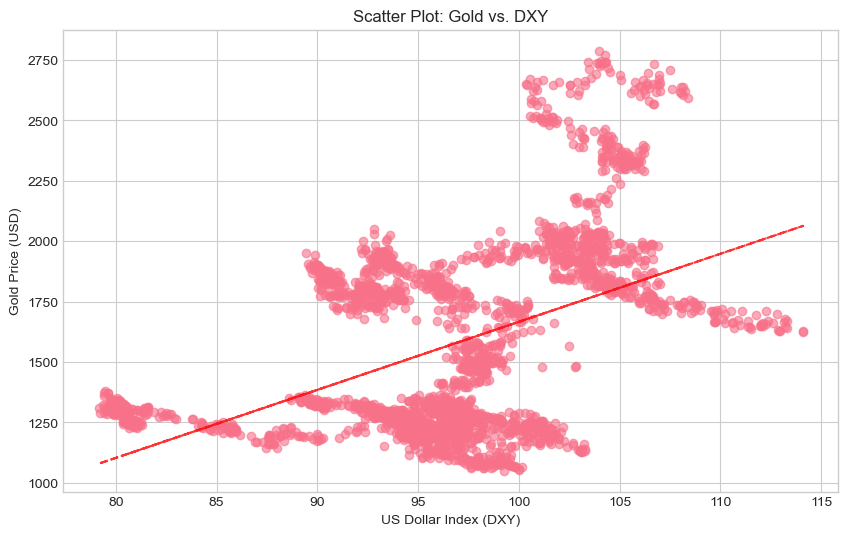

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df['DXY'], df['Gold'], alpha=0.6)
plt.xlabel('US Dollar Index (DXY)')
plt.ylabel('Gold Price (USD)')
plt.title('Scatter Plot: Gold vs. DXY')
z = np.polyfit(df['DXY'], df['Gold'], 1) # Calculate trendline
p = np.poly1d(z)
plt.plot(df['DXY'], p(df['DXY']), "r--", alpha=0.8) # Add trendline
plt.show()

In [30]:
correlation, p_value = stats.pearsonr(df['DXY'], df['Gold'])
print("Correlation Analysis (on Price Levels):")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Correlation Analysis (on Price Levels):
Pearson Correlation Coefficient: 0.4748
P-value: 0.0000


In [31]:
# This is often a more statistically sound approach
df['Gold_Returns'] = df['Gold'].pct_change() * 100
df['DXY_Returns'] = df['DXY'].pct_change() * 100
df_returns = df[['Gold_Returns', 'DXY_Returns']].dropna()

correlation_returns, p_value_returns = stats.pearsonr(df_returns['DXY_Returns'], df_returns['Gold_Returns'])
print("\nCorrelation Analysis (on Daily Returns):")
print(f"Pearson Correlation Coefficient: {correlation_returns:.4f}")
print(f"P-value: {p_value_returns:.4f}")


Correlation Analysis (on Daily Returns):
Pearson Correlation Coefficient: -0.3952
P-value: 0.0000


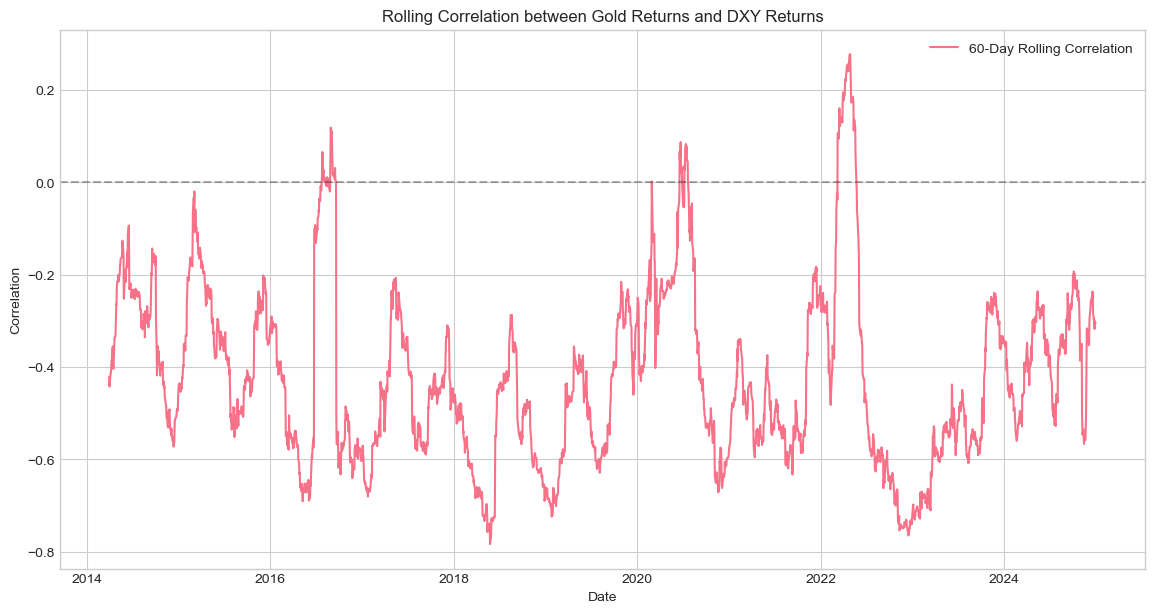

In [32]:
window = 60
df['Rolling_Correlation'] = df_returns['Gold_Returns'].rolling(window).corr(df_returns['DXY_Returns'])

plt.figure(figsize=(14, 7))
# Use df.index instead of df_returns.index to ensure dimensions match
# Also, dropna() to remove NaN values that occur at the beginning of the rolling calculation
plt.plot(df.index, df['Rolling_Correlation'], label=f'{window}-Day Rolling Correlation')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.title('Rolling Correlation between Gold Returns and DXY Returns')
plt.legend()
plt.show()


In [33]:
X = df['DXY'].dropna()
Y = df['Gold'].dropna()
# Add a constant (intercept) to the model
X = sm.add_constant(X)
# Fit the regression model
model = sm.OLS(Y, X).fit()
# Print the detailed results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     804.0
Date:                Mon, 01 Sep 2025   Prob (F-statistic):          1.90e-155
Time:                        10:57:23   Log-Likelihood:                -20037.
No. Observations:                2764   AIC:                         4.008e+04
Df Residuals:                    2762   BIC:                         4.009e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1147.7975     96.151    -11.938      0.0